In [23]:
from sklearn import datasets,svm                                # 1. scikit-learn에서 기본 데이터셋 모듈을 불러옵니다.
from sklearn.model_selection import train_test_split            # 2. 데이터를 학습용(Train)과 테스트용(Test)으로 분할하는 함수를 불러옵니다.
import numpy as np                                              # 3. 수치 연산 및 행렬 다루기를 위한 numpy 라이브러리를 불러옵니다.

iris = datasets.load_iris()                                     # 4. 내장된 붓꽃(Iris) 데이터셋(150개 데이터)을 메모리에 로드합니다.
X = iris.data                                                   # 5. 특성 데이터(Feature): 꽃잎/꽃받침 수치 4개 (2D 행렬, 대문자 X 사용)
y = iris.target                                                 # 6. 정답 데이터(Target): 붓꽃 품종 라벨 0, 1, 2 (1D 벡터, 소문자 y 사용)

print(X.shape)  # (150, 4)                                       # 7. 데이터 구조 확인: 150개의 꽃 샘플, 각 4개의 특성(Feature) 존재

(150, 4)


In [24]:
random_state = np.random.RandomState(0)                        # 1. 난수(랜덤값) 생성을 위한 시드(Seed)를 0으로 고정합니다. (실행할 때마다 같은 결과 유지)
n_samples, n_features = X.shape                                 # 2. 현재 X의 행 크기(샘플 수 150)와 열 크기(특성 수 4)를 각 변수에 저장합니다.
X = np.c_[X, random_state.randn(n_samples, 200 * n_features)]  # 3. 기존 X 데이터 옆에 800개(200 * 4)의 무작위 노이즈 특성(가짜 데이터)을 옆으로 합칩니다.

print(X.shape)  # (150, 804)                                    # 4. 데이터 구조 확인: 기존 4개 + 노이즈 800개 = 총 804개의 특성을 가진 150개 데이터 완성

(150, 804)


In [25]:
print(np.unique(y))

[0 1 2]


In [26]:
#- 0, 1 라벨에 속하는 붓꽃 샘플만 사용하도록 제한합니다.
X_train, X_test, y_train, y_test = train_test_split(X[y < 2], y[y < 2],
                                                    test_size=.5,
                                                    random_state=random_state)

print("훈련, 테스트 셋에 사용된 라벨의 종류: {} ".format( set(y_test)))
print("훈련 데이터 shape   :", X_train.shape)
print("테스트 데이터 shape :", X_test.shape)

훈련, 테스트 셋에 사용된 라벨의 종류: {np.int64(0), np.int64(1)} 
훈련 데이터 shape   : (50, 804)
테스트 데이터 shape : (50, 804)


In [27]:
classifier = svm.SVC(kernel='poly', random_state=random_state)
classifier.fit(X_train, y_train)

classifier.score(X_test,y_test)

0.48

In [28]:
classifier = svm.SVC(kernel='linear', random_state=random_state)
classifier.fit(X_train, y_train)

classifier.score(X_test,y_test)

0.8

In [29]:
classifier.predict(X_test)

array([0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1])

In [30]:
y_test

array([1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0])

In [31]:
y_score = classifier.decision_function(X_test)
print(y_score)

[-0.29512751  0.28798352  0.17635465  0.19056886  0.38391605 -0.30841065
 -0.10084254 -0.23481309  0.18576987 -0.36011033 -0.15726747 -0.25714889
 -0.14979669  0.02063898  0.04509171 -0.17239443  0.07287957 -0.0689103
 -0.13452462 -0.30697712  0.25404241 -0.28916471 -0.52061453  0.25252233
  0.02177777 -0.10980907  0.37468422  0.35303004 -0.6211302  -0.42920064
 -0.14770647  0.00593404 -0.34735296  0.32245409 -0.19439024  0.1288847
 -0.0320947  -0.23008604 -0.10135548 -0.46962186  0.05184235  0.0609688
  0.05632596  0.44769206 -0.38804349  0.24704844  0.16063684  0.0144203
 -0.03136574  0.11179177]


In [32]:
from sklearn.metrics import confusion_matrix, classification_report  # 평가 지표(오차행렬, 분류리포트) 함수 불러오기

y_pred = classifier.predict(X_test)                  # 1. 테스트 데이터(X_test)로 0과 1 정답을 예측함
conf_mat = confusion_matrix(y_test, y_pred)          # 2. 진짜 정답(y_test)과 예측값(y_pred)을 비교해 오차 행렬 작성
print(conf_mat)                                       # 3. 작성된 오차 행렬([[20, 4], [6, 20]])을 화면에 출력

rpt_result = classification_report(y_test, y_pred)   # 4. 정밀도, 재현율, F1-score 등을 종합한 리포트 생성
print(rpt_result)                                    # 5. 생성된 분류 리포트를 화면에 출력

[[20  4]
 [ 6 20]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        24
           1       0.83      0.77      0.80        26

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



In [33]:
y_pred_new_threshold = classifier.decision_function(X_test) > -0.1
conf_mat = confusion_matrix(y_test, y_pred_new_threshold)
print(conf_mat)
rpt_result = classification_report(y_test, y_pred_new_threshold)
print(rpt_result)

[[18  6]
 [ 5 21]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        24
           1       0.78      0.81      0.79        26

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50



In [34]:
y_pred_new_threshold = classifier.decision_function(X_test) > -0.2
conf_mat = confusion_matrix(y_test, y_pred_new_threshold)
print(conf_mat)
rpt_result = classification_report(y_test, y_pred_new_threshold)
print(rpt_result)

[[12 12]
 [ 2 24]]
              precision    recall  f1-score   support

           0       0.86      0.50      0.63        24
           1       0.67      0.92      0.77        26

    accuracy                           0.72        50
   macro avg       0.76      0.71      0.70        50
weighted avg       0.76      0.72      0.71        50



In [38]:
from sklearn.metrics import precision_score, recall_score

# 1. 정밀도만 딱 구하고 싶을 때
precision = precision_score(y_test, y_pred)
print(f"정밀도: {precision:.2f}")

# 2. 재현율만 딱 구하고 싶을 때
recall = recall_score(y_test, y_pred)
print(f"재현율: {recall:.2f}")

# 3. 종합 채점표 형태로 한눈에 다 보고 싶을 때 (가장 많이 씀!)
print(classification_report(y_test, y_pred))

정밀도: 0.83
재현율: 0.77
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        24
           1       0.83      0.77      0.80        26

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



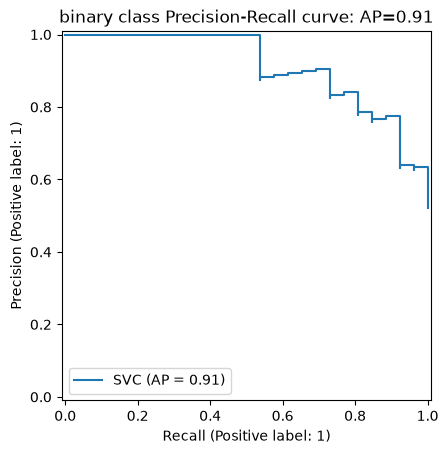

In [35]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

disp = PrecisionRecallDisplay.from_estimator(classifier, X_test, y_test)
disp.ax_.set_title('binary class Precision-Recall curve: '
                   'AP={0:0.2f}'.format(disp.average_precision))

plt.show()